In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import pickle as pkl
import pyvisa as visa
import datetime
from scipy.optimize import curve_fit
from collections import defaultdict
from scipy.stats import kurtosis, skew
import pandas as pd
from collections import OrderedDict
from pathlib import Path
import fnmatch
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font

In [4]:
rm = visa.ResourceManager()
instruments = rm.list_resources()
keithley = rm.open_resource('TCPIP::192.168.169.76::INSTR')
odp = rm.open_resource('USB0::6833::3601::DP8B260200018::0::INSTR')

In [6]:
I = float(keithley.query('MEAS:CURR:DC?'))
I

0.0263638455

In [15]:
odp.write("INST:NSEL 3")
odp.write("CURR:PROT 0.05")
odp.write("CURR 0.05")
odp.write("OUTP ON")
vdd = float(odp.query("MEAS:VOLT?"))
vdd

1.5776

In [48]:
IV = {}

In [84]:
VDS = [] 
IDS = []
for V in np.arange(0.1, 2.6, 0.1):
    odp.write("INST:NSEL 3")
    odp.write("CURR:PROT 0.05")
    odp.write(f"VOLT {V}")
    odp.write("OUTP ON")
    time.sleep(1)
    vdd = float(odp.query("MEAS:VOLT?"))
    I = float(keithley.query('MEAS:CURR:DC?'))
    VDS.append(vdd) 
    IDS.append(I)
VGS = -0.75
IV[VGS] = [VDS, IDS]

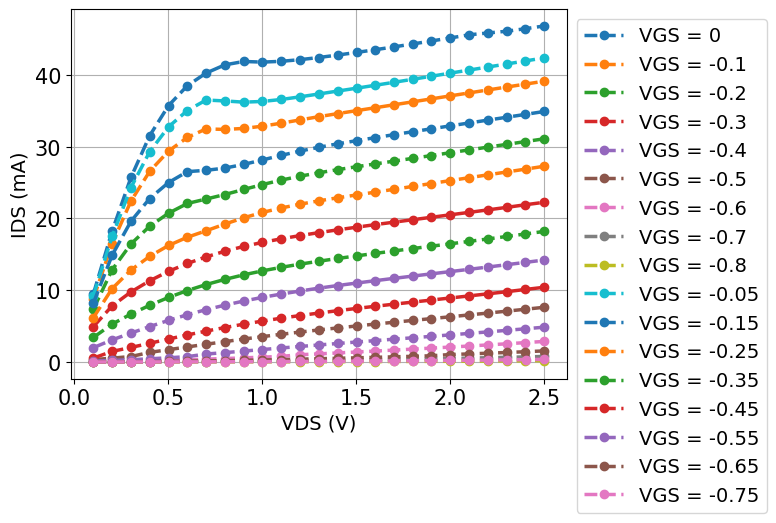

In [85]:
big_plt_font()
for VGS in IV: 
    if 1:
        vds, ids = IV[VGS]
        plot(vds, np.array(ids)*1e3, '.--', label=f'VGS = {VGS}', xlabel='VDS (V)', ylabel='IDS (mA)')
plt.legend(bbox_to_anchor=(1.,1)) 
plt.show()

In [148]:
np.savez('HEMT_IV_xihu888_0.npz', IV)

In [145]:
VDS = [] 
IDS = []
for V in np.arange(0.1, 2.6, 0.1):
    odp.write("INST:NSEL 3")
    odp.write("CURR:PROT 0.05")
    odp.write(f"VOLT {V}")
    odp.write("OUTP ON")
    time.sleep(1)
    vdd = float(odp.query("MEAS:VOLT?"))
    I = float(keithley.query('MEAS:CURR:DC?'))
    VDS.append(vdd) 
    IDS.append(I)
VGS = -0.85
IV[VGS] = [VDS, IDS]

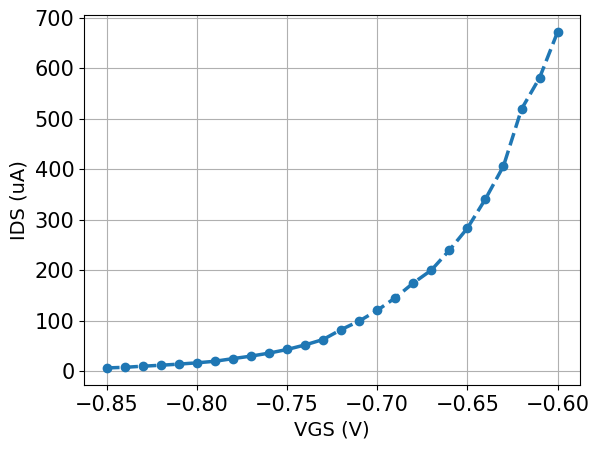

In [146]:
ID_VG = [] 
VGS_sort = np.sort([_ for _ in IV])
for VGS in VGS_sort: 
    vds, ids = IV[VGS] 
    id_vg = np.array(ids)[np.argmin(abs(np.array(vds) - 1))] 
    ID_VG.append(id_vg) 
ID_VG = np.array(ID_VG)
VGS_sort = np.array(VGS_sort) 
ID_sel_idx = np.where(ID_VG < 1e-3) 
ID_sel = ID_VG[ID_sel_idx] 
VGS_sel = VGS_sort[ID_sel_idx]
plot(VGS_sel, ID_sel*1e6, '.--', xlabel='VGS (V)', ylabel='IDS (uA)')

In [144]:
ID_sel[0]*1e6

np.float64(7.43841249)

In [154]:
def get_gm_id(ids, vgs):
    """
    Calculates gm/ID given arrays of IDS and VGS.
    Assumes VGS is sorted/monotonic.
    
    Returns:
        np.array: The gm/ID ratio.
    """
    ids = np.array(ids)
    vgs = np.array(vgs)
    
    # Calculate Transconductance: gm = d(IDS) / d(VGS)
    gm = np.gradient(ids, vgs)
    
    # Calculate gm/ID
    # We use 'where' to handle division by zero safely
    with np.errstate(divide='ignore', invalid='ignore'):
        gm_id = np.where(ids != 0, gm / ids, np.nan)
        
    return gm_id

def get_ro(ids, vds):
    """
    Calculates Output Resistance (ro) given arrays of IDS and VDS.
    Assumes VDS is sorted/monotonic.
    
    Returns:
        np.array: The Output Resistance (ro).
    """
    ids = np.array(ids)
    vds = np.array(vds)
    
    # Calculate Output Conductance: gds = d(IDS) / d(VDS)
    gds = np.gradient(ids, vds)
    
    # Calculate Output Resistance: ro = 1 / gds
    with np.errstate(divide='ignore', invalid='ignore'):
        ro = np.where(gds != 0, 1.0 / gds, np.nan)
        
    return ro

In [152]:
id_fixedVgs, vd_fixedVds = IV[-0.69]

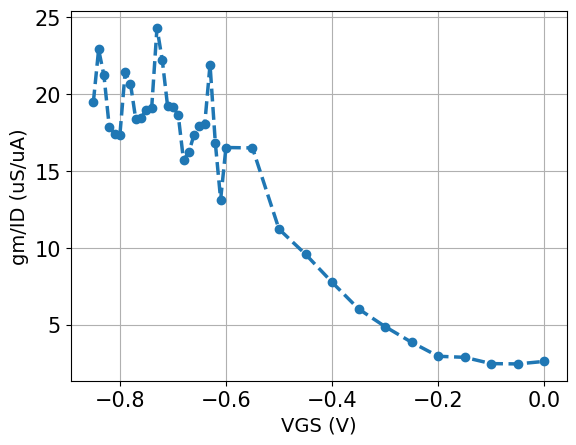

In [159]:
plot(VGS_sort, get_gm_id(ID_VG, VGS_sort), '.--', xlabel='VGS (V)', ylabel='gm/ID (uS/uA)')

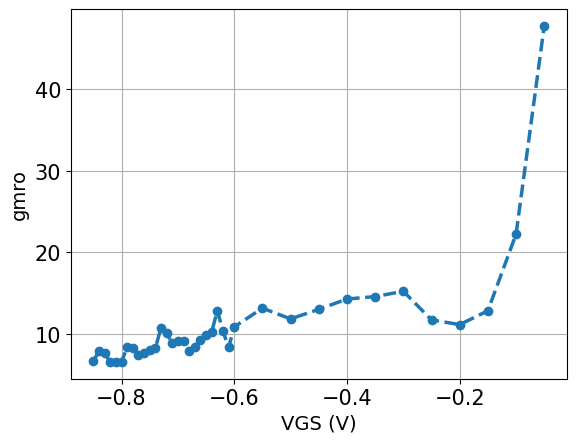

In [174]:
ro_list = [] 
for vg in VGS_sort: 
    vds, ids = IV[vg] 
    ids, vds = np.array(ids), np.array(vds)
    ro = get_ro(ids, vds) 
    ro_1 = ro[np.argmin(abs(vds-1))] 
    ro_list.append(ro_1) 
    
ro_array = np.array(ro_list) 
plot(VGS_sort[:-1], (get_gm_id(ID_VG, VGS_sort)*ID_VG*ro_array)[:-1], '.--', xlabel='VGS (V)', ylabel='gmro')

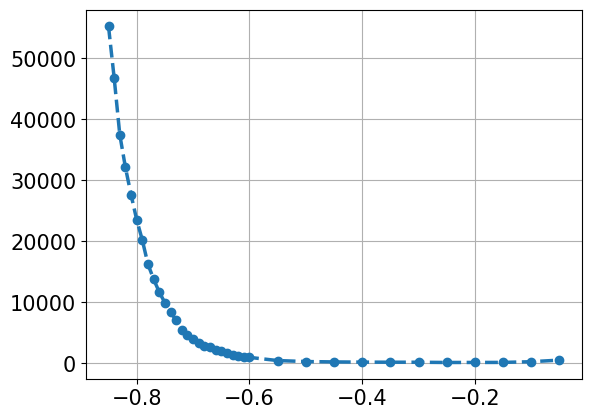

In [173]:
plot(VGS_sort[:-1], (ro_array)[:-1], '.--')